In [10]:
# ---- importing functions ----
import sys
import numpy as np

# importing slow dynamics pipeline
pipeline_dir = 'C:/Users/ys2605/Desktop/stuff/slow_dynamics_analysis'    # edit this  
sys.path.append(pipeline_dir + '/functions')
import sd_utils as sd
import sd_decoder as dec

seed = 0           # integer for reproducible results, or None for random

In [11]:
# ---- Save figures as along the way ---- 
save_figs = True  # can turn on or off to save figures or not
fig_dir = 'C:/Users/ys2605/Desktop/stuff/papers/AC_paper_protocol/figures/python_decoder_comb'    # edit this

In [12]:
# ---- loading mismatch CaIm datasets ----
# for external datasets these steps need to be modified
data_dir = 'F:/AC_data/caiman_data_missmatch/'   # edit this 
 
# loading raw firing rates, trial types, and stimuli times from oddball dataset
# returns a list of dicts (one per dataset); main field 'firing_rates' is (neurons, time)
data_ob = sd.load_caim_data_mat(
    data_dir,                            # data directory
    ext_list=['mat'],                    # data extension
    tags=['ammn', '_processed_data'],    # data tags
    num_files=20,                        # limit number of files to load
    deconvolution='oasis',               # deconvolution oasis or smoothdfdt
    smooth_std_duration=0.1)             # in sec

frame_rate = 1000/np.mean(sd.get_values(data_ob, 'volume_period')) # in Hz; edit this for external datasets

Loaded 20 datasets from 2 mice: [np.str_('M1'), np.str_('M2')]


In [13]:
# ---- loading RNN neuronal activity during control inputs ----
# three types of RNNs trainings: oddball recognition, control freq recognition, and untrained
# all three were tested with control inputs and neuronal activity was extracted
# returns a list of dicts (one per network); firing_rates is (neurons, time) if flatten_runs else (runs, neurons, time)
data_dir_rnn = 'F:/RNN_stuff/RNN_data/test_data/'
fname_rnn = 'RNN_test_data_2024_5_24_9h_42m2'
data_rnn = sd.load_rnn_test(
    data_dir_rnn, 
    fname_rnn + '_cont_data.npy',
    fname_rnn + '_params.npy',
    max_net_load = 5,               # max networks per type (lower = less memory)
    flatten_runs = True,            # False: 3D (runs, neurons, time); True: 2D (neurons, time)
    max_trial_types = 10,           # keep first N stimulus types (flattened only)
    max_trials = 400,               # keep first N trials (flattened only)
    limit_network_types=['ob trained', 'freq trained'],     # types to load; [] = all
    seed=seed)                      # reproducibility seed (None = random)

frame_rate_rnn = 1000/np.mean(sd.get_values(data_rnn, 'volume_period')) # in Hz; edit this for external datasets
training_type = np.array(sd.get_values(data_rnn, 'training'))

Loaded 10 RNN networks: {np.str_('freq trained'): 5, np.str_('ob trained'): 5}


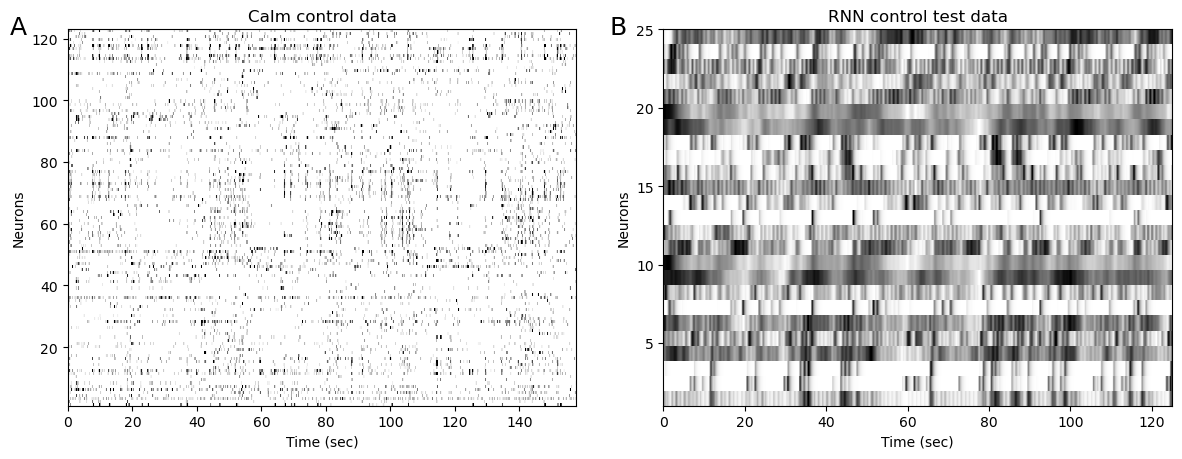

In [14]:
# ---- plot example raster ----
fig = sd.plot_fig_raster(
    data_ob[0]['firing_rates'][:,500:5000],
    sd.normalize(data_rnn[0]['firing_rates'][:,2000:4500]),
    frame_rate=frame_rate,
    frame_rate_rnn=frame_rate_rnn)

# ---- save figure ----
if save_figs:    
    sd.save_fig(fig, path=fig_dir, name_tag='Fig 1 Joint data rnn raster')

In [15]:
# ---- CaIm data extracting trials using stimulus times ----
# compute trial window frames (assuming all datasets have similar frame rate)
trial_frames, plot_t = sd.get_frames(
    trial_win=[-1,3],         # sec relative to stim onset (pre, post)
    frame_rate=frame_rate)

# extract stimulus triggered average matrix (neurons, frames, trials)
stim_trig_resp_all = []
for n_fl in range(len(data_ob)):  
    stim_trig_resp = sd.get_stim_trig_resp(
        data_ob[n_fl]['firing_rates'],    # firing rates
        data_ob[n_fl]['stim_times'],      # stimulus onset frames
        trial_frames=trial_frames)        # frames to be extracted
    
    stim_trig_resp_all.append(stim_trig_resp)

In [16]:
# ---- RNN tested with control inputs ----
# RNN compute trial window frames for stim triggered ave
trial_frames_rnn, plot_t_rnn = sd.get_frames(
    trial_win=[-1,5],         # sec relative to stim onset (pre, post)
    frame_rate=frame_rate_rnn)

# computing stimulus triggered average (neurons, frames, trials)
stim_trig_resp_all_rnn = []
for n_fl in range(len(data_rnn)):  
    stim_trig_resp = sd.get_stim_trig_resp(
        data_rnn[n_fl]['firing_rates'],    # firing rates
        data_rnn[n_fl]['stim_times'],      # stimulus onset frames
        trial_frames=trial_frames_rnn)     # frames to be extracted
    
    stim_trig_resp_all_rnn.append(stim_trig_resp)

In [17]:
# ---- Define diagonal binwise decoder ----
def f_diag_decoder(stim_trig_resp, trial_types, seed=None):
    # the same responses are passed twice in X_all; the control is the label-shuffled
    # version in Y_all (trial labels shuffled), not a second, different dataset
    X_all = [stim_trig_resp,
             stim_trig_resp]

    Y_all = [trial_types,
             dec.shuffle_trials(trial_types, seed=seed)]   # label-shuffled control
    
    dec_data = dec.run_binwise_dec(
        X_all,
        Y_all,
        train_test_method='diag',   # options: full, diag, train_at_stim, test_at_stim
        pca_var_frac=1,             # reduce data with pca
        num_cv=5,                   # cross validation
        normalize=False,
        add_noise_sigma=1e-5,       # for stability 
        get_train_coeffs=True, seed=seed)

    return dec_data

In [18]:
# ---- Run for all CaIm datasets ----
dec_data_all = []
for n_fl in range(len(data_ob)):
    print('Training dataset %d/%d' % (n_fl+1, len(stim_trig_resp_all)))

    trial_types = data_ob[n_fl]['trial_types']
    trial_types_use = trial_types<10     # select trials to use

    dec_data = f_diag_decoder(
        stim_trig_resp_all[n_fl][:,:,trial_types_use],
        trial_types[trial_types_use], seed=seed)

    dec_data_all.append(dec_data)
print('Done')

Training dataset 1/20
Training dataset 2/20
Training dataset 3/20
Training dataset 4/20
Training dataset 5/20
Training dataset 6/20
Training dataset 7/20
Training dataset 8/20
Training dataset 9/20
Training dataset 10/20
Training dataset 11/20
Training dataset 12/20
Training dataset 13/20
Training dataset 14/20
Training dataset 15/20
Training dataset 16/20
Training dataset 17/20
Training dataset 18/20
Training dataset 19/20
Training dataset 20/20
Done


In [19]:
# ---- Run for all RNN datasets ----
dec_data_all_rnn = []
for n_fl in range(len(data_rnn)):
    print('Training dataset %d/%d' % (n_fl+1, len(stim_trig_resp_all_rnn)))

    dec_data = f_diag_decoder(
        stim_trig_resp_all_rnn[n_fl],
        data_rnn[n_fl]['trial_types'], seed=seed)

    dec_data_all_rnn.append(dec_data)
    
print('Done')   

Training dataset 1/10
Training dataset 2/10
Training dataset 3/10
Training dataset 4/10
Training dataset 5/10
Training dataset 6/10
Training dataset 7/10
Training dataset 8/10
Training dataset 9/10
Training dataset 10/10
Done


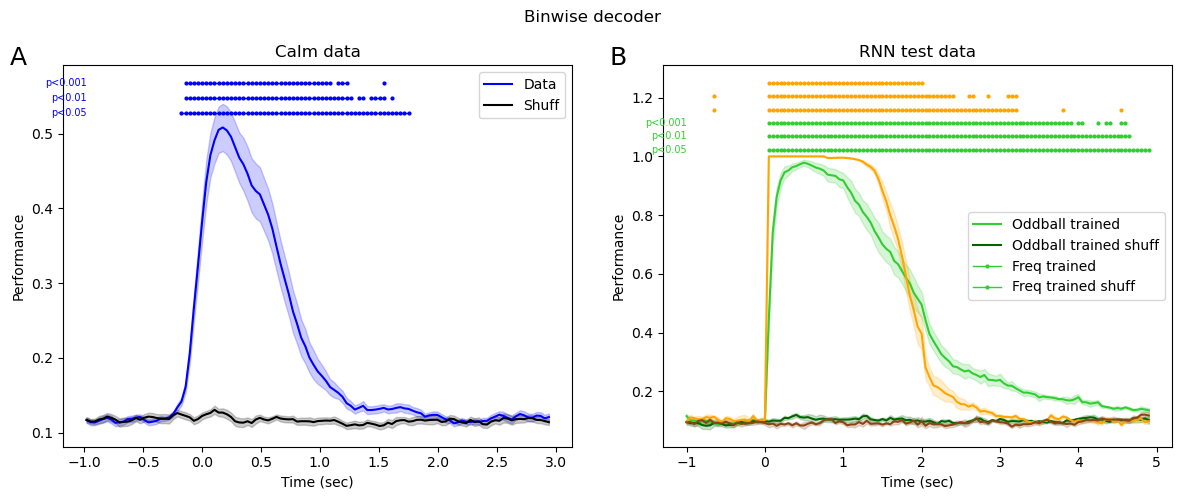

In [20]:
# ---- Plotting diagonal decoder results ----
fig_diag = sd.plot_fig_diag_decoder(
    dec_data_all,
    dec_data_all_rnn,
    training_type,
    plot_t=plot_t,
    plot_t_rnn=plot_t_rnn)

# ---- save figure ----
if save_figs:    
    sd.save_fig(fig_diag, path=fig_dir, name_tag='Fig 1 joint binwise decoder')

In [ ]:
# ---- Define full decoding space binwise decoder ----
def f_full_decoder(stim_trig_resp, trial_types, seed=None):
    # the same responses are passed twice in X_all; the control is the label-shuffled
    # version in Y_all (trial labels shuffled), not a second, different dataset
    X_all = [stim_trig_resp,
             stim_trig_resp]

    Y_all = [trial_types,
             dec.shuffle_trials(trial_types, seed=seed)]   # label-shuffled control
    
    dec_data = dec.run_binwise_dec(
        X_all,
        Y_all,
        train_test_method='full',   # options: full, diag, train_at_stim, test_at_stim
        pca_var_frac=1,             # reduce data with pca
        num_cv=5,                   # cross validation
        normalize=False,
        add_noise_sigma=1e-5,       # for stability 
        log=True, seed=seed)
    return dec_data

In [9]:
# ---- Run example CaIm dataset ---- 
n_fl = 2      # select dataset

trial_types = data_ob[n_fl]['trial_types']
trial_types_use = trial_types<10     # select trials to use

dec_data_full = f_full_decoder(
    stim_trig_resp_all[n_fl][:,:,trial_types_use],
    trial_types[trial_types_use], seed=seed)

print('Done')

dset 1 of 2; train bin 0/114
dset 1 of 2; train bin 1/114
dset 1 of 2; train bin 2/114
dset 1 of 2; train bin 3/114
dset 1 of 2; train bin 4/114
dset 1 of 2; train bin 5/114
dset 1 of 2; train bin 6/114
dset 1 of 2; train bin 7/114
dset 1 of 2; train bin 8/114
dset 1 of 2; train bin 9/114
dset 1 of 2; train bin 10/114
dset 1 of 2; train bin 11/114
dset 1 of 2; train bin 12/114
dset 1 of 2; train bin 13/114
dset 1 of 2; train bin 14/114
dset 1 of 2; train bin 15/114
dset 1 of 2; train bin 16/114
dset 1 of 2; train bin 17/114
dset 1 of 2; train bin 18/114
dset 1 of 2; train bin 19/114
dset 1 of 2; train bin 20/114
dset 1 of 2; train bin 21/114
dset 1 of 2; train bin 22/114
dset 1 of 2; train bin 23/114
dset 1 of 2; train bin 24/114
dset 1 of 2; train bin 25/114
dset 1 of 2; train bin 26/114
dset 1 of 2; train bin 27/114
dset 1 of 2; train bin 28/114
dset 1 of 2; train bin 29/114
dset 1 of 2; train bin 30/114
dset 1 of 2; train bin 31/114
dset 1 of 2; train bin 32/114
dset 1 of 2; train b

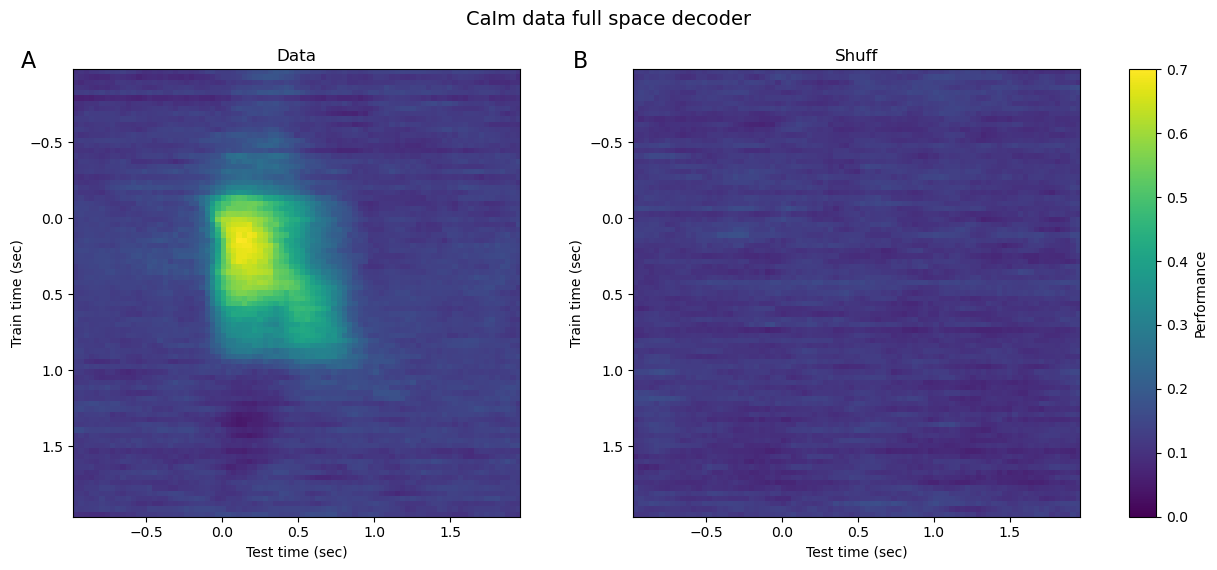

In [10]:
# ---- Plotting full decoder results CaIm data ----
fig_full = sd.plot_fig_full_decoder_caim(
    dec_data_full,
    plot_t,
    clim=[0, 0.7])

if save_figs:
    sd.save_fig(fig_full, path=fig_dir, name_tag='')
    

In [16]:
# ---- Run example RNN datasets ---- 
n_fl = np.where(training_type == 'ob trained')[0][0]
dec_data_full_ob = f_full_decoder(
    stim_trig_resp_all_rnn[n_fl],
    data_rnn[n_fl]['trial_types'], seed=seed)

n_fl = np.where(training_type == 'freq trained')[0][0]
dec_data_full_freq = f_full_decoder(
    stim_trig_resp_all_rnn[n_fl],
    data_rnn[n_fl]['trial_types'], seed=seed)

print('Done')

dset 1 of 2; train bin 0/120
dset 1 of 2; train bin 1/120
dset 1 of 2; train bin 2/120
dset 1 of 2; train bin 3/120
dset 1 of 2; train bin 4/120
dset 1 of 2; train bin 5/120
dset 1 of 2; train bin 6/120
dset 1 of 2; train bin 7/120
dset 1 of 2; train bin 8/120
dset 1 of 2; train bin 9/120
dset 1 of 2; train bin 10/120
dset 1 of 2; train bin 11/120
dset 1 of 2; train bin 12/120
dset 1 of 2; train bin 13/120
dset 1 of 2; train bin 14/120
dset 1 of 2; train bin 15/120
dset 1 of 2; train bin 16/120
dset 1 of 2; train bin 17/120
dset 1 of 2; train bin 18/120
dset 1 of 2; train bin 19/120
dset 1 of 2; train bin 20/120
dset 1 of 2; train bin 21/120
dset 1 of 2; train bin 22/120
dset 1 of 2; train bin 23/120
dset 1 of 2; train bin 24/120
dset 1 of 2; train bin 25/120
dset 1 of 2; train bin 26/120
dset 1 of 2; train bin 27/120
dset 1 of 2; train bin 28/120
dset 1 of 2; train bin 29/120
dset 1 of 2; train bin 30/120
dset 1 of 2; train bin 31/120
dset 1 of 2; train bin 32/120
dset 1 of 2; train b

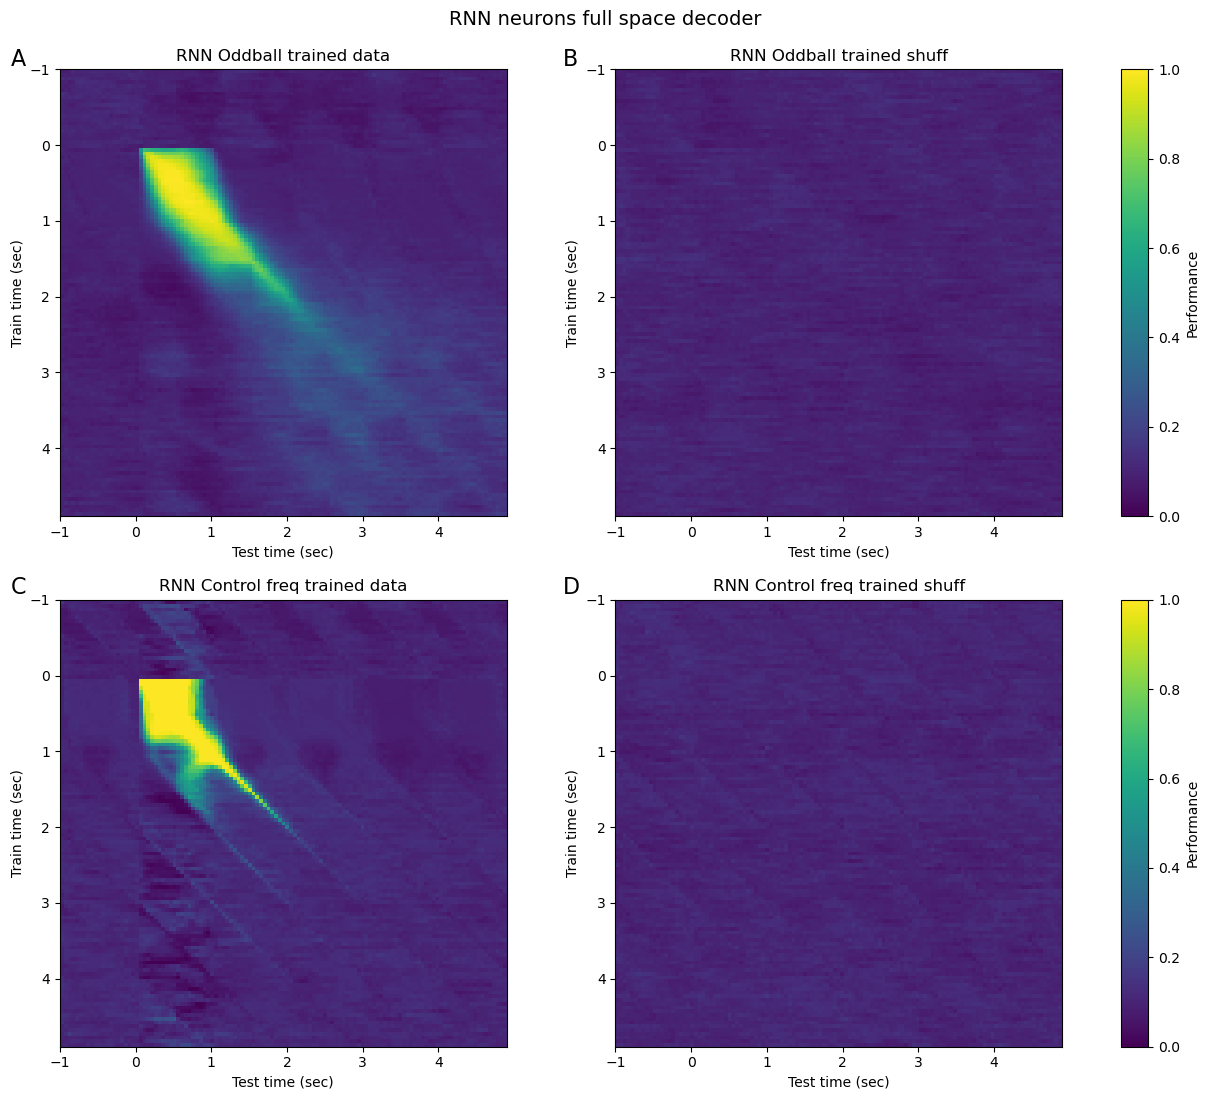

In [20]:
# ---- Plotting full decoder results RNN data ----
fig_full = sd.plot_fig_full_decoder_RNN(
    dec_data_full_ob,
    dec_data_full_freq,
    plot_t_rnn)

if save_figs:
    sd.save_fig(fig_full, path=fig_dir, name_tag='')